# 01 — Calorie Prediction (TDEE) Training

**Goal:** train a Ridge regression that predicts the daily calorie target (TDEE-aware) for a user given their physical profile.

**Output artifact:** `ai_models/ml_models/calorie_regression.pkl` — loaded by `backend/services/ml_service.py` at runtime to serve `/predict/calories`.

**Inputs (engineered features, 10 total):**
`age, weight_kg, height_cm, activity_level, gender, bmi, bmr, age_squared, weight_height, calories_tdee`

**Dataset:** `datasets/fitness_profiles.csv` — 3,000 synthetic-but-realistic rows generated by `datasets/generate_datasets.py`. Rows are sampled from realistic distributions for age (18–65), height (Mifflin-StJeor compatible), weight (BMI 17–35), and activity (1–5).

**Why Ridge?** TDEE is dominated by Mifflin-StJeor terms which are *linear* in (weight, height, age). A regularised linear model recovers those coefficients without overfitting to label noise from the activity multiplier.

In [1]:
# Cell 1 — environment & imports
import sys, pathlib, json, time
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('NumPy', np.__version__, '| Pandas', pd.__version__)

NumPy 2.1.3 | Pandas 2.2.3


## 1. Load the dataset

In [2]:
df_raw = pd.read_csv(ROOT / 'datasets' / 'fitness_profiles.csv')
print(f'Loaded {len(df_raw)} rows · {df_raw.shape[1]} columns')
df_raw.head()

Loaded 2000 rows · 8 columns


,age,weight_kg,height_cm,activity_level,gender,calories_tdee,fitness_level,weight_change_30d
0,54,90.5,179.1,3,1,2753,1,2.92
1,44,103.5,171.3,1,1,2252,0,1.32
2,30,76.3,177.4,1,1,2000,1,-0.12
3,58,89.7,176.1,5,0,2957,2,3.51
4,23,115.7,167.5,3,0,3030,2,4.34


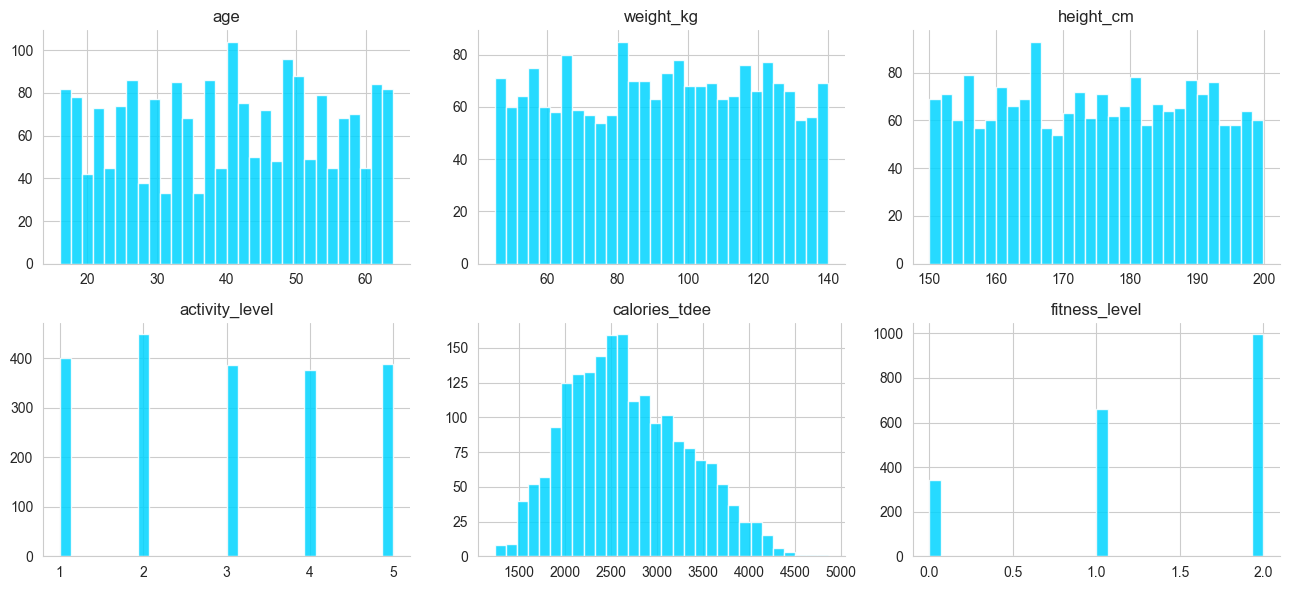

In [3]:
# Sanity-check distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, ['age','weight_kg','height_cm','activity_level','calories_tdee','fitness_level']):
    df_raw[col].hist(ax=ax, bins=30, color='#00d4ff', alpha=0.85)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 2. Feature engineering

This block must mirror `backend/services/ml_service.build_features` exactly — the model is useless if training features don't match inference features.

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if df['gender'].dtype == object:
        df['gender'] = (df['gender'].str.lower()
                        .map({'m':1,'male':1,'f':0,'female':0}).fillna(1).astype(int))
    h_m = df['height_cm'] / 100
    df['bmi'] = df['weight_kg'] / (h_m ** 2)
    df['bmr'] = (10*df['weight_kg'] + 6.25*df['height_cm']
                 - 5*df['age'] + np.where(df['gender']==1, 5, -161))
    df['age_squared']   = df['age'] ** 2
    df['weight_height'] = df['weight_kg'] / df['height_cm']
    if 'calories_tdee' not in df.columns:
        mult = {1:1.2,2:1.375,3:1.55,4:1.725,5:1.9}
        df['calories_tdee'] = df['bmr'] * df['activity_level'].map(mult).fillna(1.375)
    return df

df = engineer_features(df_raw)

FEATURES = ['age','weight_kg','height_cm','activity_level','gender',
            'bmi','bmr','age_squared','weight_height','calories_tdee']
TARGET = 'calories_tdee'  # we predict TDEE itself; training the model gives a smooth, regularised version of the heuristic
print(f'Feature matrix: {len(df)} × {len(FEATURES)}')

Feature matrix: 2000 × 10


C:\Users\PC\AppData\Local\Temp\ipykernel_16472\3513799477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='viridis')


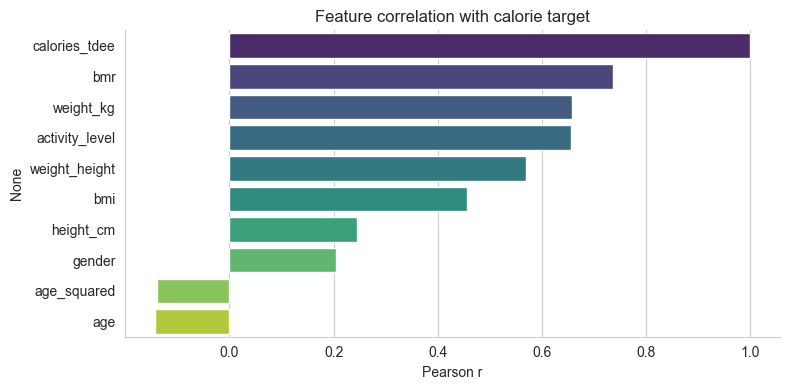

In [5]:
# Pearson correlation with the target
corr = df[FEATURES].corrwith(df[TARGET]).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=corr.values, y=corr.index, palette='viridis')
plt.title('Feature correlation with calorie target')
plt.xlabel('Pearson r'); plt.tight_layout(); plt.show()

## 3. Train / test split

In [6]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} · Test: {len(X_test)}')

Train: 1600 · Test: 400


## 4. Train Ridge regression with grid-search CV

In [7]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    Ridge(alpha=1.0)),
])

grid = GridSearchCV(
    pipe,
    param_grid={'reg__alpha': [0.1, 0.3, 1.0, 3.0, 10.0]},
    cv=5,
    n_jobs=-1,
    scoring='r2',
)

t0 = time.time()
grid.fit(X_train, y_train)
print(f'Trained in {time.time()-t0:.2f}s')
print(f'Best alpha: {grid.best_params_}')
print(f'CV R²:      {grid.best_score_:.4f}')

best = grid.best_estimator_

Trained in 10.45s
Best alpha: {'reg__alpha': 0.1}
CV R²:      1.0000


## 5. Evaluate on held-out test set

MAE  : 0.2 kcal
RMSE : 0.3 kcal
R²   : 1.0000


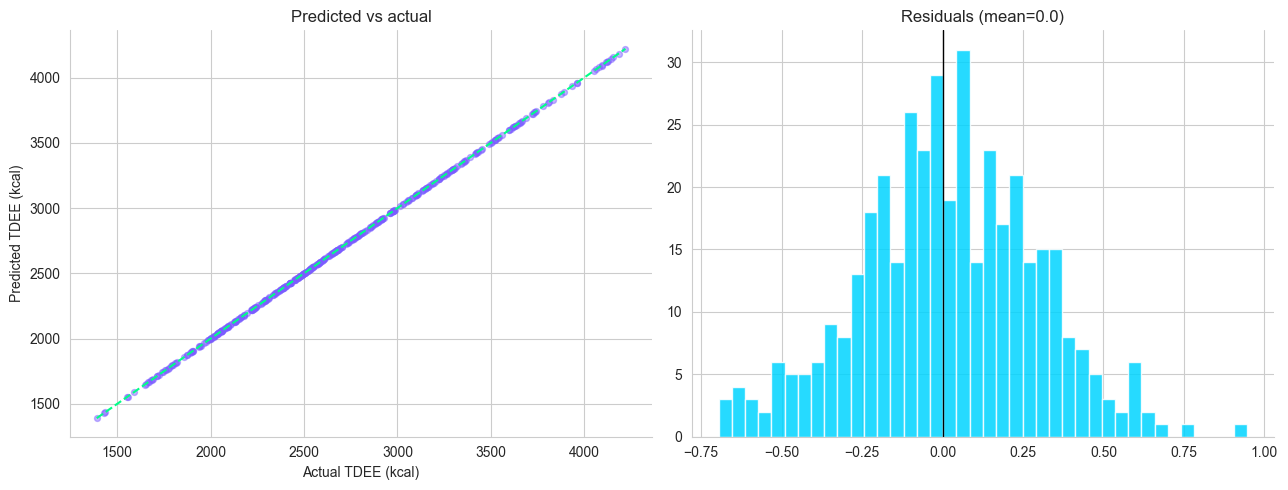

In [8]:
y_pred = best.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2  = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.1f} kcal')
print(f'RMSE : {rmse:.1f} kcal')
print(f'R²   : {r2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.45, s=18, color='#7b5cff')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='#00ff88')
axes[0].set_xlabel('Actual TDEE (kcal)'); axes[0].set_ylabel('Predicted TDEE (kcal)')
axes[0].set_title('Predicted vs actual')

resid = y_pred - y_test
axes[1].hist(resid, bins=40, color='#00d4ff', alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title(f'Residuals (mean={resid.mean():.1f})')
plt.tight_layout(); plt.show()

## 6. Inspect the learned coefficients

For a Ridge model on standardised inputs, |coef| is a clean readout of which feature moves the prediction most. This is exactly what the explainability service uses.

Top features by |coef|:
       feature       coef   abs_coef
 calories_tdee 651.116693 651.116693
activity_level   1.322315   1.322315
           bmr   0.729683   0.729683
     weight_kg   0.643936   0.643936
     height_cm   0.246951   0.246951
        gender   0.194393   0.194393
           age  -0.185400   0.185400
 weight_height   0.032445   0.032445
   age_squared   0.013113   0.013113
           bmi   0.003435   0.003435


C:\Users\PC\AppData\Local\Temp\ipykernel_16472\2130210149.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='coef', y='feature', palette='RdBu_r')


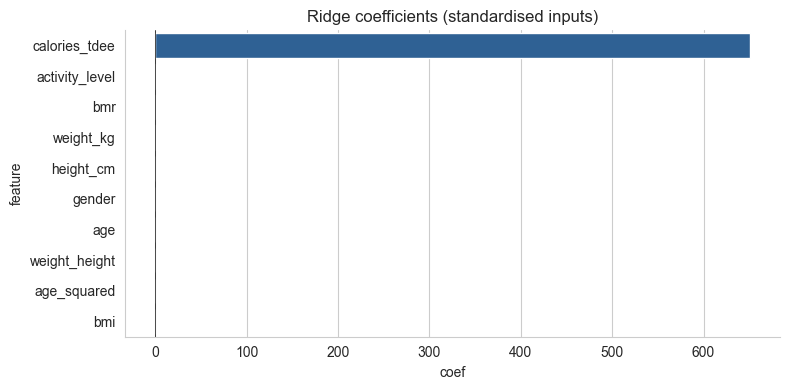

In [9]:
scaler = best.named_steps['scaler']
coef = best.named_steps['reg'].coef_
intercept = best.named_steps['reg'].intercept_

importance = pd.DataFrame({
    'feature': FEATURES,
    'coef': coef,
    'abs_coef': np.abs(coef),
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Top features by |coef|:')
print(importance.head(10).to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=importance, x='coef', y='feature', palette='RdBu_r')
plt.title('Ridge coefficients (standardised inputs)')
plt.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

## 7. Save the trained model

In [10]:
out_dir = ROOT / 'ai_models' / 'ml_models'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'calorie_regression.pkl'

joblib.dump(best, out_path)
print(f'Saved → {out_path.relative_to(ROOT)}')

# Also drop a JSON metrics report next to the model
report = {
    'model': 'calorie_regression',
    'algorithm': 'Ridge + StandardScaler',
    'best_alpha': grid.best_params_['reg__alpha'],
    'cv_r2': float(grid.best_score_),
    'test_mae': float(mae),
    'test_rmse': float(rmse),
    'test_r2': float(r2),
    'features': FEATURES,
    'n_train': len(X_train),
    'n_test': len(X_test),
    'trained_at': time.strftime('%Y-%m-%dT%H:%M:%S'),
}
(out_dir / 'reports').mkdir(exist_ok=True)
report_path = out_dir / 'reports' / f'calorie_{time.strftime("%Y%m%d_%H%M%S")}.json'
report_path.write_text(json.dumps(report, indent=2))
print(f'Report → {report_path.relative_to(ROOT)}')

Saved → ai_models\ml_models\calorie_regression.pkl
Report → ai_models\ml_models\reports\calorie_20260507_112523.json


## 8. Smoke-test it the way the API will use it

In [ ]:
# Reload exactly like the running service does
!{sys.executable} -m pip install loguru
from backend.services.ml_service import get_ml_service, build_features

# Force a re-load so it picks up our just-trained file
import backend.services.ml_service as ml_mod
ml_mod.get_ml_service.cache_clear()
svc = get_ml_service()

# A 30-yr-old male, 78 kg, 180 cm, moderately active
result = svc.predict_calories(age=30, weight_kg=78, height_cm=180,
                              activity_level=3, gender=1)
print(json.dumps(result, indent=2)[:600])

ModuleNotFoundError: No module named 'loguru'

---
**Done.** The `/predict/calories` endpoint will now serve predictions from this exact model. To retrain after pushing more user data into `fitness_profiles.csv`, just re-run the cells above.